# 01 — Exploratory Data Analysis
## Propensity Model

**Цели:**
- понять структуру/качество данных, дисбаланс таргета
- проверить даты и выбрать TRAIN_END / VALID_END
- найти проблемы в данных, определить полезные фичи


## 0. Импорт библиотек, настройка параметров

In [45]:
import sys, warnings
from pathlib import Path

# Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR.parent / "data"

sys.path.insert(0, str(PROJECT_DIR / "src"))

warnings.filterwarnings("ignore")

# Libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from config import (DATA_FILES, HORIZON_DAYS, ACTIVE_WINDOW_DAYS, RISK_LEVEL_CANONICAL, INVESTMENT_CAPACITY_CANONICAL)

from data_loader import (load_transactions, load_customers, load_assets, load_close_prices, load_markets, get_customer_profile_at)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    #"grid.alpha": 0.3,
    "font.size": 10,
})

BLUE = "#2563EB"
RED = "#DC2626"
GREEN = "#16A34A"
GREY = "#94A3B8"
ORANGE = "#EA580C"

EDA_DIR = PROJECT_DIR / "outputs" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR.resolve())
print("DATA_DIR:", DATA_DIR.resolve())

PROJECT_DIR: /Users/egor/Documents/Учеба файлы/ВКР/project/propensity_model
DATA_DIR: /Users/egor/Documents/Учеба файлы/ВКР/project/data


## 1. Загрузка файлов датасета

In [46]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

tx = load_transactions(DATA_DIR / "transactions.csv")
cust = load_customers(DATA_DIR / "customer_information.csv")
assets = load_assets(DATA_DIR / "asset_information.csv")
prices = load_close_prices(DATA_DIR / "close_prices.csv")
markets = load_markets(DATA_DIR / "markets.csv")

print(f"\nРазмеры датасетов:")
print(f"transactions: {tx.shape}")
print(f"customers: {cust.shape}")
print(f"assets: {assets.shape}")
print(f"close_prices: {prices.shape}")
print(f"markets: {markets.shape}")

Загрузка транзакций из /Users/egor/Documents/Учеба файлы/ВКР/project/data/transactions.csv
Транзакции: 388,048 → 359,128 очищенные (удалено 28,920)
Покупка/Продажа: 213,639 / 145,489
Загрузка данных клиентов из /Users/egor/Documents/Учеба файлы/ВКР/project/data/customer_information.csv
  Клиенты: 32,468 rows, 29,090 уникальных ID
Загрузка активов из /Users/egor/Documents/Учеба файлы/ВКР/project/data/asset_information.csv
Assets: 836 → 806 уникальных ISIN (категории: {'MTF': 313, 'Stock': 284, 'Bond': 209})
Загрузка цен закрытия из /Users/egor/Documents/Учеба файлы/ВКР/project/data/close_prices.csv
Цены: 703,303 → 703,303 очищенные, 807 уникальных ISIN, за период 2018-01-01 – 2022-11-29
Загрузка данных по рынкам из /Users/egor/Documents/Учеба файлы/ВКР/project/data/markets.csv
  Рынки: 38 записей



Размеры датасетов:
transactions: (359128, 10)
customers: (32468, 8)
assets: (806, 9)
close_prices: (703303, 3)
markets: (38, 8)


## 2. Анализ транзакций

In [47]:
print("=== ТРАНЗАКЦИИ: СТАТИСТИКА ===")
print(tx.dtypes)
print()
print(tx.describe())

=== ТРАНЗАКЦИИ: СТАТИСТИКА ===
customerID                 object
ISIN                       object
transactionID               int64
transactionType            object
timestamp          datetime64[ns]
totalValue                float64
units                     float64
channel                    object
marketID                   object
is_synthetic                int64
dtype: object

       transactionID                      timestamp    totalValue  \
count   3.591280e+05                         359128  3.591280e+05   
mean    7.798404e+06  2020-09-14 01:13:05.582856192  8.447033e+03   
min    -3.934400e+04            2018-01-02 00:00:00  2.831069e-16   
25%     7.453746e+06            2020-01-31 00:00:00  4.700000e+02   
50%     8.126848e+06            2020-12-10 00:00:00  1.322000e+03   
75%     9.795990e+06            2021-11-03 00:00:00  3.555000e+03   
max     1.187415e+07            2022-11-30 00:00:00  2.715912e+07   
std     3.079127e+06                            NaN  1.964607e

In [48]:
print("Типы транзакций:")
print(tx["transactionType"].value_counts())
print()
print("Каналы:")
print(tx["channel"].value_counts())

Типы транзакций:
transactionType
Buy     213639
Sell    145489
Name: count, dtype: int64

Каналы:
channel
Internet Banking    237378
Branch               61413
Phone Banking        60337
Name: count, dtype: int64


In [49]:
# Временной охват данных
print(f"Временной охват: {tx['timestamp'].min().date()} → {tx['timestamp'].max().date()}")
print(f"Всего дней: {(tx['timestamp'].max() - tx['timestamp'].min()).days}")
print(f"Уникальных покупателей: {tx['customerID'].nunique():,}")
print(f"Уникальных продуктов: {tx['ISIN'].nunique():,}")

Временной охват: 2018-01-02 → 2022-11-30
Всего дней: 1793
Уникальных покупателей: 28,227
Уникальных продуктов: 320


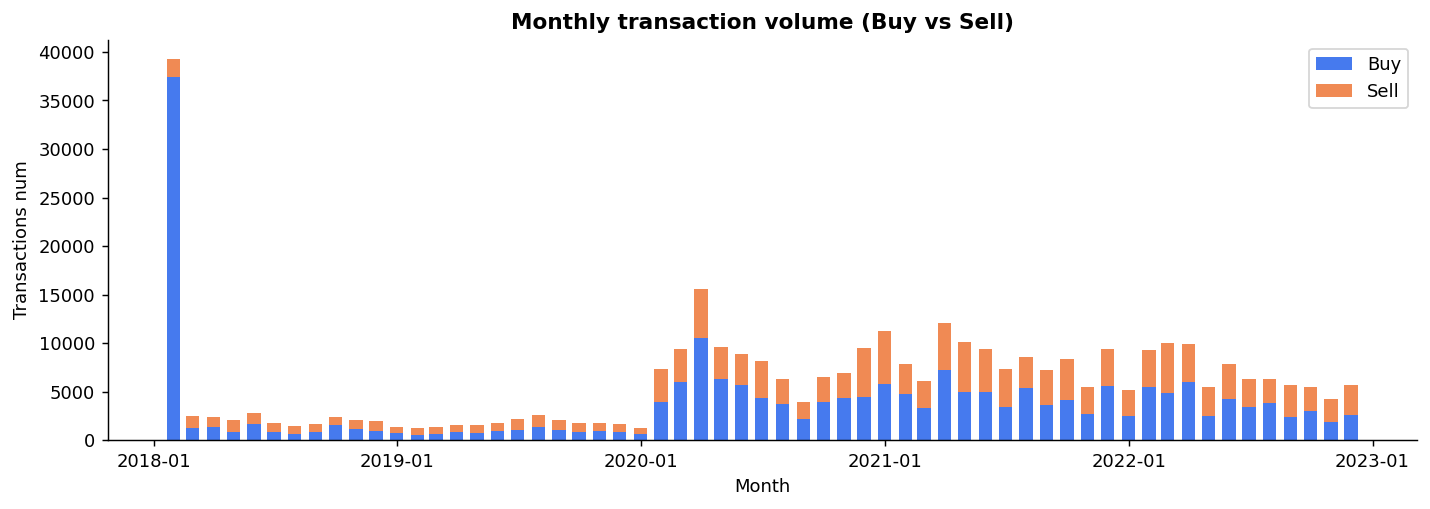

In [50]:
# Количество транзакций за каждый месяц
monthly = (tx.set_index("timestamp").groupby([pd.Grouper(freq="ME"), "transactionType"]).size().unstack(fill_value=0).reset_index())

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly["timestamp"], monthly.get("Buy", 0), label="Buy",  color=BLUE,  alpha=0.85, width=20)
ax.bar(monthly["timestamp"], monthly.get("Sell", 0), label="Sell", color=ORANGE, alpha=0.7,  width=20, bottom=monthly.get("Buy", 0))

ax.set_title("Monthly transaction volume (Buy vs Sell)", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Transactions num")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.savefig(EDA_DIR / "monthly_volume.png", dpi=150, bbox_inches="tight")
plt.show()

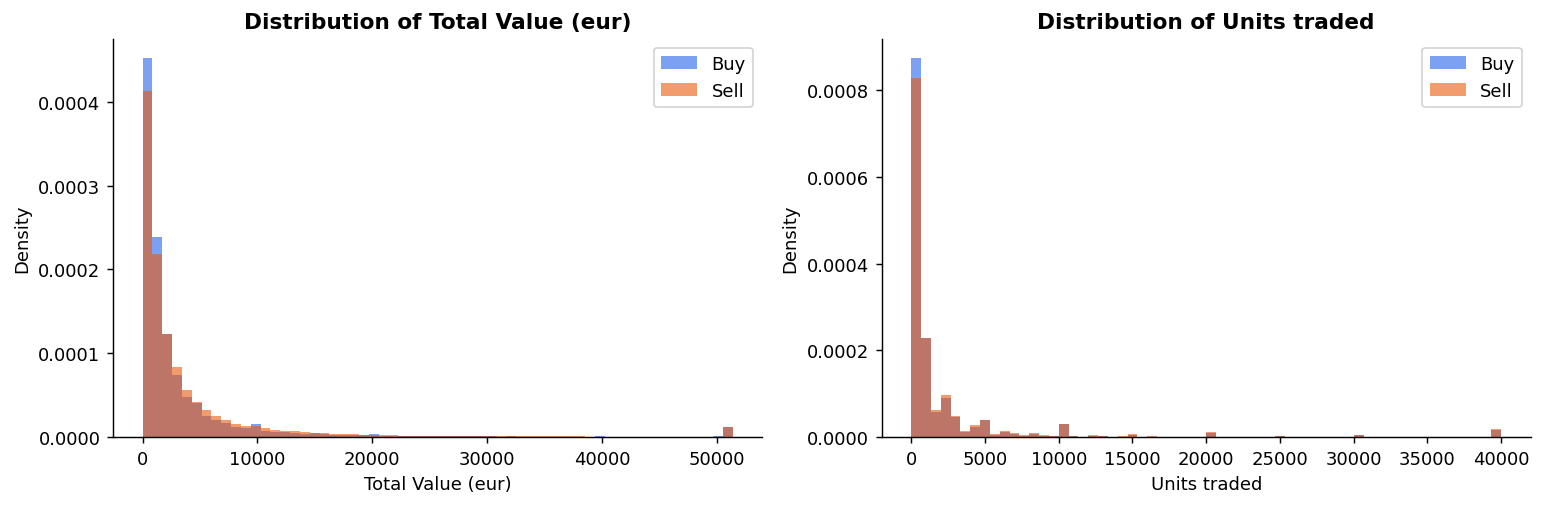

Покупка 
totalValue — median: €1230  mean: €8910
Продажа 
totalValue — median: €1480  mean: €7767


In [51]:
# Распределение сумм сделок
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in [
    (axes[0], "totalValue", "Total Value (eur)"),
    (axes[1], "units", "Units traded"),
]:
    buys  = tx[tx["transactionType"] == "Buy"][col].clip(upper=tx[col].quantile(0.99))
    sells = tx[tx["transactionType"] == "Sell"][col].clip(upper=tx[col].quantile(0.99))
    ax.hist(buys,  bins=60, alpha=0.6, color=BLUE,   label="Buy",  density=True)
    ax.hist(sells, bins=60, alpha=0.6, color=ORANGE,  label="Sell", density=True)
    ax.set_title(f"Distribution of {label}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend()
    
plt.tight_layout()
plt.savefig(EDA_DIR / "value_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Покупка \ntotalValue — median: €{tx[tx['transactionType']=='Buy']['totalValue'].median():.0f}  "
      f"mean: €{tx[tx['transactionType']=='Buy']['totalValue'].mean():.0f}")
print(f"Продажа \ntotalValue — median: €{tx[tx['transactionType']=='Sell']['totalValue'].median():.0f}  "
      f"mean: €{tx[tx['transactionType']=='Sell']['totalValue'].mean():.0f}")


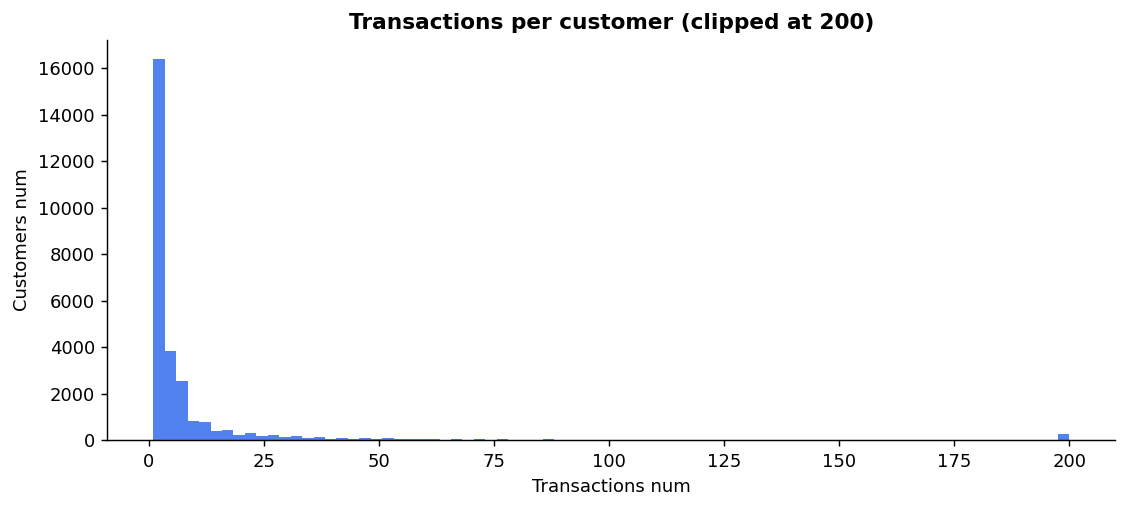

count    28227.000000
mean        12.722854
std         67.680599
min          1.000000
50%          2.000000
75%          6.000000
90%         20.000000
95%         44.000000
99%        188.740000
max       6288.000000
dtype: float64


In [52]:
# Количество транзакций на одного клиента
tx_per_customer = tx.groupby("customerID").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tx_per_customer.clip(upper=200), bins=80, color=BLUE, alpha=0.8)
ax.set_title("Transactions per customer (clipped at 200)", fontweight="bold")
ax.set_xlabel("Transactions num")
ax.set_ylabel("Customers num")

plt.savefig(EDA_DIR / "tx_per_customer.png", dpi=150, bbox_inches="tight")
plt.show()

print(tx_per_customer.describe(percentiles=[.50, .75, .90, .95, .99]))

## 3. Профили клиентов

In [53]:
print("=== КЛИЕНТЫ: СТАТИСТИКА ===")
print(f"Строк всего: {len(cust):,}")
print(f"Уникальных клиентов: {cust['customerID'].nunique():,}")
print(f"Строк на клиента (среднее): {len(cust) / cust['customerID'].nunique():.1f}")
print()
print("Строк на клиента (статистики):")
print(cust.groupby("customerID").size().describe())

=== КЛИЕНТЫ: СТАТИСТИКА ===
Строк всего: 32,468
Уникальных клиентов: 29,090
Строк на клиента (среднее): 1.1

Строк на клиента (статистики):
count    29090.000000
mean         1.116122
std          0.470730
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          9.000000
dtype: float64


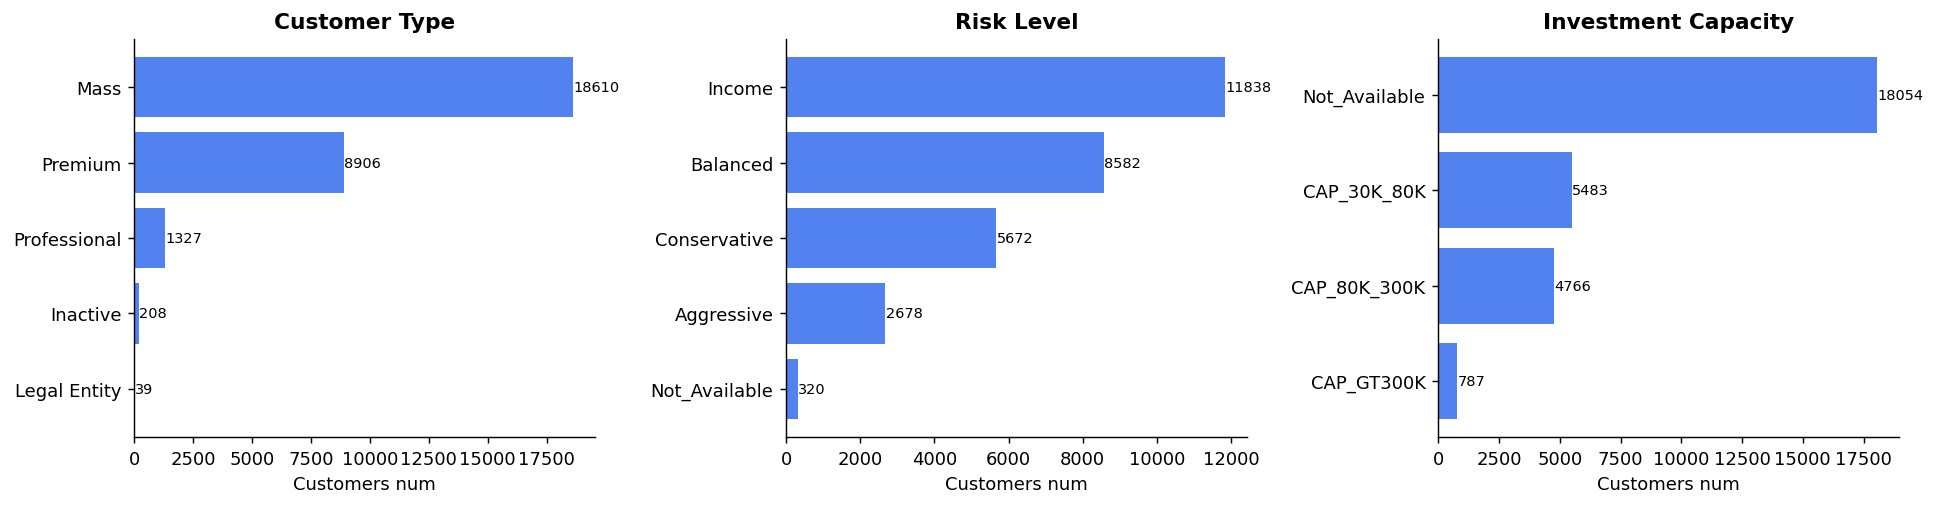

In [54]:
# Распределение категориальных признаков профиля клиента
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = ["Customer Type", "Risk Level", "Investment Capacity"]

for ax, col, title in zip(axes, ["customerType", "riskLevel", "investmentCapacity"], titles):
    latest = cust.sort_values("timestamp").groupby("customerID").last() # Берем последний статус профиля
    vc = latest[col].value_counts().sort_values(ascending=True) 
    ax.barh(vc.index, vc.values, color=BLUE, alpha=0.8)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Customers num")
    for i, v in enumerate(vc.values):
        ax.text(v + 5, i, str(v), va="center", fontsize=8)

plt.tight_layout()
plt.savefig(EDA_DIR / "customer_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# Сравнение прогнозируемого и фактического уровня риска
latest_cust = cust.sort_values("timestamp").groupby("customerID").last().reset_index()
predicted_share = latest_cust["is_profile_predicted"].mean()
print(f"Доля клиентов с предсказанными полями профиля: {predicted_share:.1%}")
print()
print("Распределение уровней риска (каноническое):")
print(latest_cust["riskLevel"].value_counts())

Доля клиентов с предсказанными полями профиля: 25.2%

Распределение уровней риска (каноническое):
riskLevel
Income           11838
Balanced          8582
Conservative      5672
Aggressive        2678
Not_Available      320
Name: count, dtype: int64


## 4. Анализ активов

In [56]:
print("=== АКТИВЫ: СТАТИСТИКА ===")
print(assets["assetCategory"].value_counts())
print()
print("Топ-10 секторов активов:")
print(assets["sector"].value_counts().head(10))

=== АКТИВЫ: СТАТИСТИКА ===
assetCategory
MTF      313
Stock    284
Bond     209
Name: count, dtype: int64

Топ-10 секторов активов:
sector
Corporate                 149
Sovereign                  49
Industrials                44
Consumer Cyclical          41
Technology                 26
Financial Services         24
Basic Materials            19
Consumer Defensive         18
Communication Services     13
Healthcare                 12
Name: count, dtype: int64


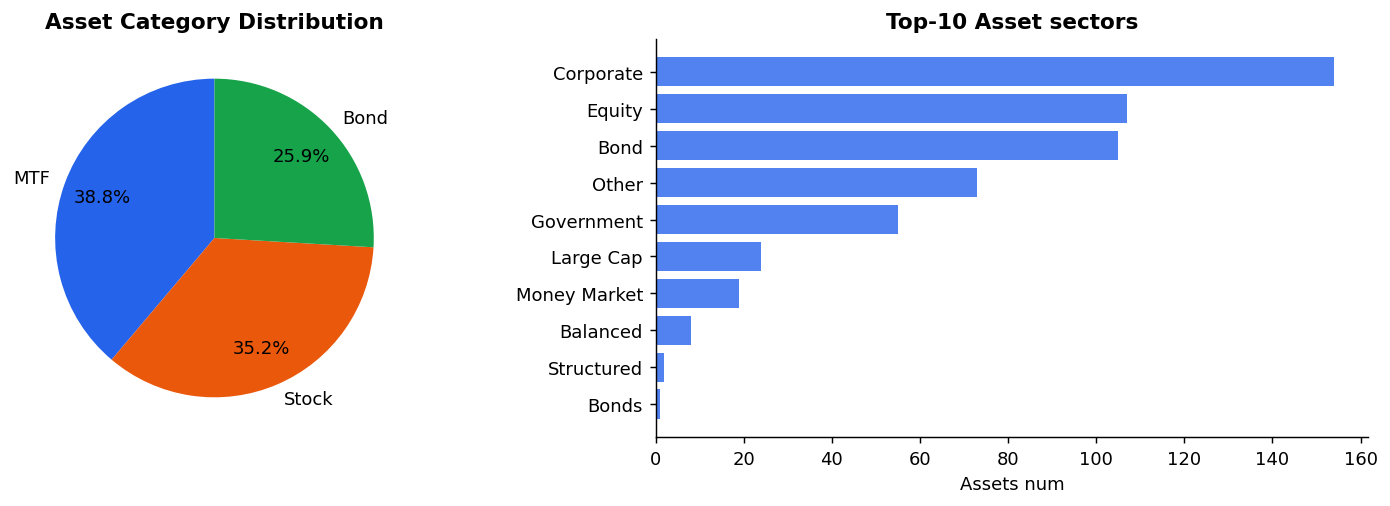

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Типы активов
cat_vc = assets["assetCategory"].value_counts()
axes[0].pie(cat_vc.values, labels=cat_vc.index,autopct="%1.1f%%", colors=[BLUE, ORANGE, GREEN], startangle=90, pctdistance=0.75)
axes[0].set_title("Asset Category Distribution", fontweight="bold")

# Топ-10 секторов
sub_vc = assets["assetSubCategory"].value_counts().head(10).iloc[::-1]
axes[1].barh(sub_vc.index, sub_vc.values, color=BLUE, alpha=0.8)
axes[1].set_title("Top-10 Asset sectors", fontweight="bold")
axes[1].set_xlabel("Assets num")

plt.tight_layout()
plt.savefig(EDA_DIR / "asset_universe.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Качество ценовых данных

In [58]:
print("=== ЦЕНЫ: СТАТИСТИКА ===")
print(f"ISIN с ценами: {prices['ISIN'].nunique():,}")
print(f"Временной охват: {prices['timestamp'].min().date()} → {prices['timestamp'].max().date()}")
print()
# Покрытие: сколько инструментов (ISIN) из asset_information имеют ценовые данные
asset_isins = set(assets["ISIN"])
price_isins = set(prices["ISIN"])
print(f"ISIN в asset_information: {len(asset_isins):,}")
print(f"ISIN с ценами: {len(price_isins):,}")
print(f"Покрытие: {len(asset_isins & price_isins) / len(asset_isins):.1%}")
print(f"ISIN с ценами но без инфо по активу: {len(price_isins - asset_isins):,}")

=== ЦЕНЫ: СТАТИСТИКА ===
ISIN с ценами: 807
Временной охват: 2018-01-01 → 2022-11-29

ISIN в asset_information: 806
ISIN с ценами: 807
Покрытие: 100.0%
ISIN с ценами но без инфо по активу: 1


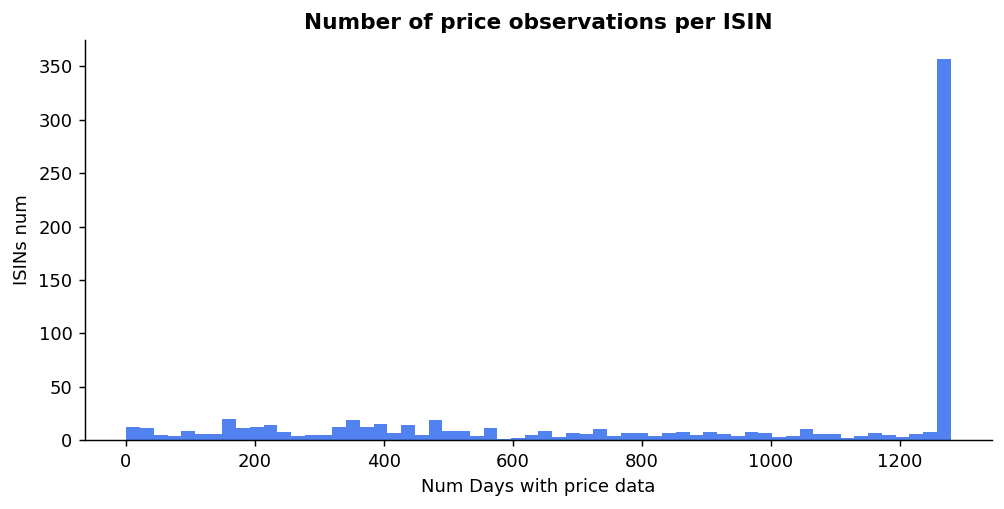

count     807.000000
mean      871.503098
std       447.357729
min         1.000000
25%       440.500000
50%      1072.000000
75%      1278.000000
95%      1278.000000
max      1279.000000
Name: timestamp, dtype: float64


In [59]:
# Длина ценовых рядов для каждого ISIN
days_per_isin = prices.groupby("ISIN")["timestamp"].nunique()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(days_per_isin, bins=60, color=BLUE, alpha=0.8)
ax.set_title("Number of price observations per ISIN", fontweight="bold")
ax.set_xlabel("Num Days with price data")
ax.set_ylabel("ISINs num")

plt.savefig(EDA_DIR / "price_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print(days_per_isin.describe(percentiles=[.25, .50, .75, .95]))


## 6. Анализ таргета, дисбаланс классов

Симулируем логику построения таргета из dataset_builder.py, чтобы понять дисбаланс положительного класса перед выбором TRAIN_END / VALID_END


In [60]:
# Симулируем таргеты для каждого возможного месяца снапшота
# используем месячную гранулярность для ускорения EDA
min_date = tx["timestamp"].min() + pd.Timedelta(days=ACTIVE_WINDOW_DAYS)
max_date = tx["timestamp"].max() - pd.Timedelta(days=HORIZON_DAYS)
sample_dates = pd.date_range(min_date, max_date, freq="ME")

records = []
for snap_date in sample_dates:
    tx_hist = tx[tx["timestamp"] <= snap_date]
    cutoff = snap_date - pd.Timedelta(days=ACTIVE_WINDOW_DAYS)
    active = tx_hist[tx_hist["timestamp"] > cutoff]["customerID"].unique()

    future_end = snap_date + pd.Timedelta(days=HORIZON_DAYS)
    buyers = tx[
        (tx["timestamp"] > snap_date) &
        (tx["timestamp"] <= future_end) &
        (tx["transactionType"] == "Buy") &
        (tx["customerID"].isin(active))
    ]["customerID"].unique()

    n_total = len(active)
    n_buyers = len(buyers)
    records.append({
        "snapshot_date": snap_date,
        "n_active": n_total,
        "n_buyers": n_buyers,
        "pos_rate": n_buyers / n_total if n_total > 0 else 0,
    })

imbalance_df = pd.DataFrame(records)
print(imbalance_df.to_string(index=False))


snapshot_date  n_active  n_buyers  pos_rate
   2019-01-31      4254       167  0.039257
   2019-02-28      4122       215  0.052159
   2019-03-31      4031       206  0.051104
   2019-04-30      3946       261  0.066143
   2019-05-31      3678       272  0.073953
   2019-06-30      3613       321  0.088846
   2019-07-31      3588       286  0.079710
   2019-08-31      3486       223  0.063970
   2019-09-30      3073       278  0.090465
   2019-10-31      3051       249  0.081613
   2019-11-30      3053       218  0.071405
   2019-12-31      2953       329  0.111412
   2020-01-31      4607      1078  0.233992
   2020-02-29      6056      1650  0.272457
   2020-03-31      7457      1490  0.199812
   2020-04-30      7805      1632  0.209097
   2020-05-31      8182      1243  0.151919
   2020-06-30      8463      1156  0.136595
   2020-07-31      8665       774  0.089325
   2020-08-31      8768      1349  0.153855
   2020-09-30      9088      1479  0.162742
   2020-10-31      9423      126

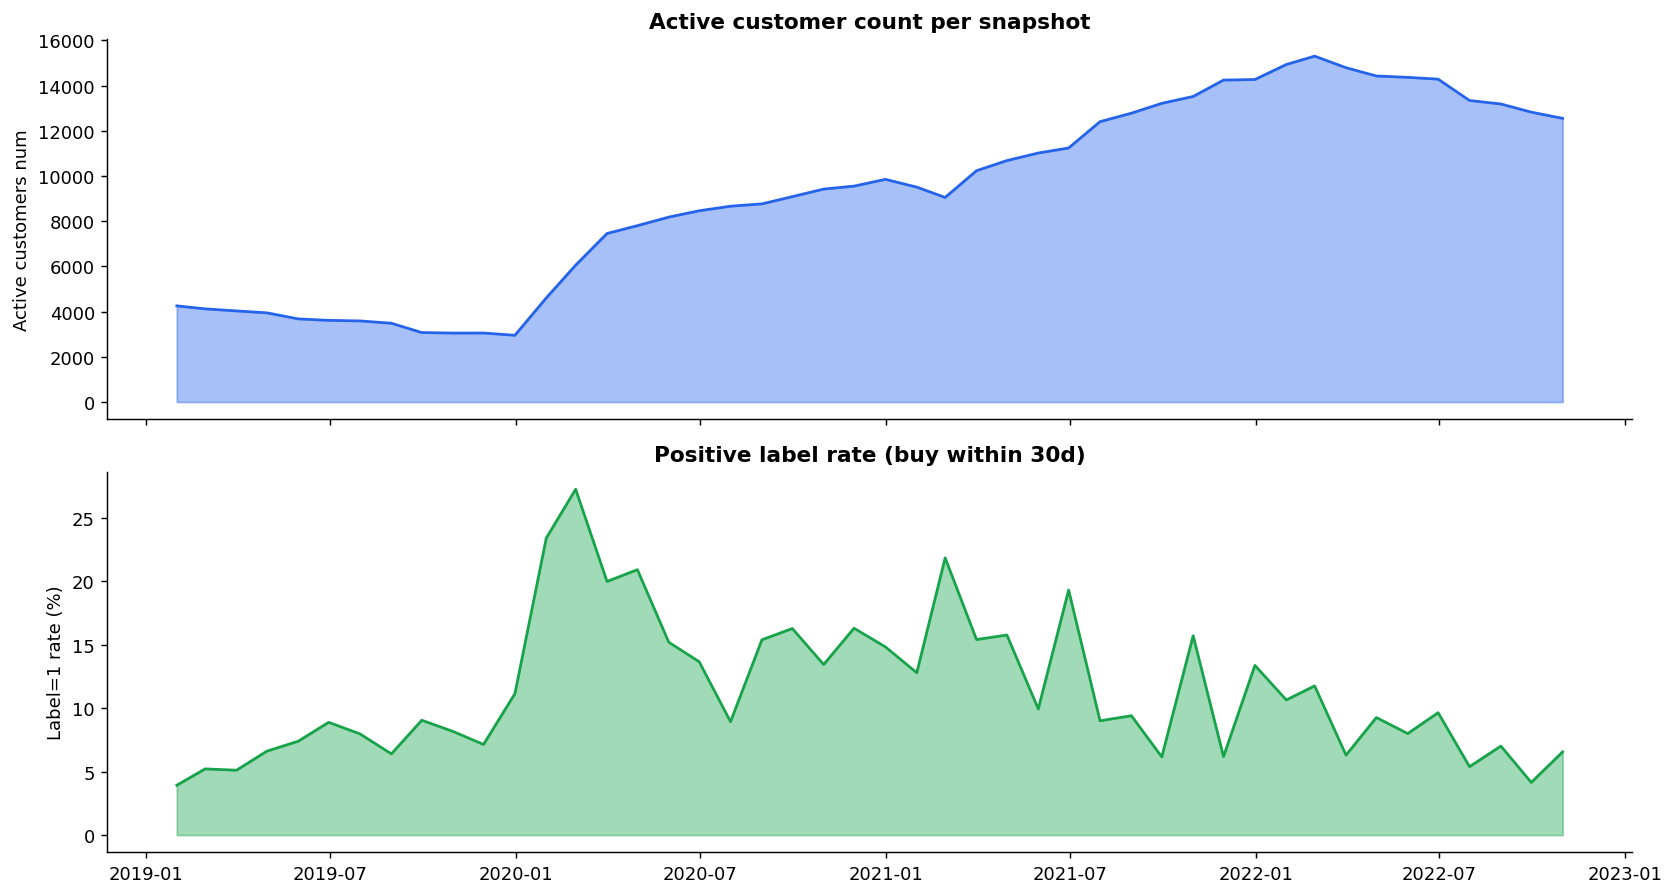


Доля положительного класса:

Median: 9.52%
Mean: 11.44%
Min: 3.93%
Max: 27.25%


In [61]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# # Количество активных клиентов за период
axes[0].fill_between(imbalance_df["snapshot_date"], imbalance_df["n_active"], alpha=0.4, color=BLUE)
axes[0].plot(imbalance_df["snapshot_date"], imbalance_df["n_active"], color=BLUE, lw=1.5)
axes[0].set_ylabel("Active customers num")
axes[0].set_title("Active customer count per snapshot", fontweight="bold")

# Доля положительного класса (% клиентов, которые купят в следующие 30 дней)
axes[1].fill_between(imbalance_df["snapshot_date"], imbalance_df["pos_rate"] * 100, alpha=0.4, color=GREEN)
axes[1].plot(imbalance_df["snapshot_date"], imbalance_df["pos_rate"] * 100, color=GREEN, lw=1.5)
axes[1].set_ylabel("Label=1 rate (%)")
axes[1].set_title(f"Positive label rate (buy within {HORIZON_DAYS}d)", fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(EDA_DIR / "class_imbalance_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

print('\nДоля положительного класса:')
print(f"\nMedian: {imbalance_df['pos_rate'].median():.2%}")
print(f"Mean: {imbalance_df['pos_rate'].mean():.2%}")
print(f"Min: {imbalance_df['pos_rate'].min():.2%}")
print(f"Max: {imbalance_df['pos_rate'].max():.2%}")


1. **Дисбаланс классов явно выражен**
- На большинстве месяцев положительный класс (купившие) составляет менее 20% - сильный дисбаланс
- В 2020–2021 есть периоды ~25–31%, но в целом положительных клиентов меньше отрицательных
2. **Влияние временного фактора**
- Рост клиентской базы и всплески активности влияют на pos_rate
- При выборе TRAIN_END / VALID_END нужно учитывать, что 2020 был «аномальным» годом с высокой активностью

**Выводы:**
- Нужно взвешивать классы или использовать методы балансировки (class_weight, oversampling) при обучении
- Для оценки модели учитывать сезонные/структурные изменения (например, 2020 год)

## 7. Калибровка дат train / valid / test

Используем результаты анализа дисбаланса (секция 6), чтобы выбрать TRAIN_END и VALID_END

Правила:
- Train: ~60-70% временного диапазона
- Valid: ~15-20%
- Test: ~15-20% (самые свежие данные)
- Каждое разделение должно содержать хотя бы ~500 положительных примеров

In [62]:
total_days  = (tx["timestamp"].max() - tx["timestamp"].min()).days
print(f"Всего дней: {total_days} days")
print(f"Граница для 60%: {tx['timestamp'].min() + pd.Timedelta(days=int(total_days * 0.60))}")
print(f"Граница для 75%: {tx['timestamp'].min() + pd.Timedelta(days=int(total_days * 0.75))}")
print()
print("Помесячные доли положительного класса:")
for _, row in imbalance_df.iterrows():
    print(f"{str(row['snapshot_date'].date())[:7]}  {row['n_buyers']:>6,} купили  "
          f"({row['pos_rate']:.1%})")
print()
print("Результаты используются для обновления TRAIN_END и VALID_END в config.py")

Всего дней: 1793 days
Граница для 60%: 2020-12-12 00:00:00
Граница для 75%: 2021-09-07 00:00:00

Помесячные доли положительного класса:
2019-01     167 купили  (3.9%)
2019-02     215 купили  (5.2%)
2019-03     206 купили  (5.1%)
2019-04     261 купили  (6.6%)
2019-05     272 купили  (7.4%)
2019-06     321 купили  (8.9%)
2019-07     286 купили  (8.0%)
2019-08     223 купили  (6.4%)
2019-09     278 купили  (9.0%)
2019-10     249 купили  (8.2%)
2019-11     218 купили  (7.1%)
2019-12     329 купили  (11.1%)
2020-01   1,078 купили  (23.4%)
2020-02   1,650 купили  (27.2%)
2020-03   1,490 купили  (20.0%)
2020-04   1,632 купили  (20.9%)
2020-05   1,243 купили  (15.2%)
2020-06   1,156 купили  (13.7%)
2020-07     774 купили  (8.9%)
2020-08   1,349 купили  (15.4%)
2020-09   1,479 купили  (16.3%)
2020-10   1,266 купили  (13.4%)
2020-11   1,557 купили  (16.3%)
2020-12   1,461 купили  (14.8%)
2021-01   1,216 купили  (12.8%)
2021-02   1,977 купили  (21.8%)
2021-03   1,577 купили  (15.4%)
2021-04   1,

## 8. Поведенческие паттерны

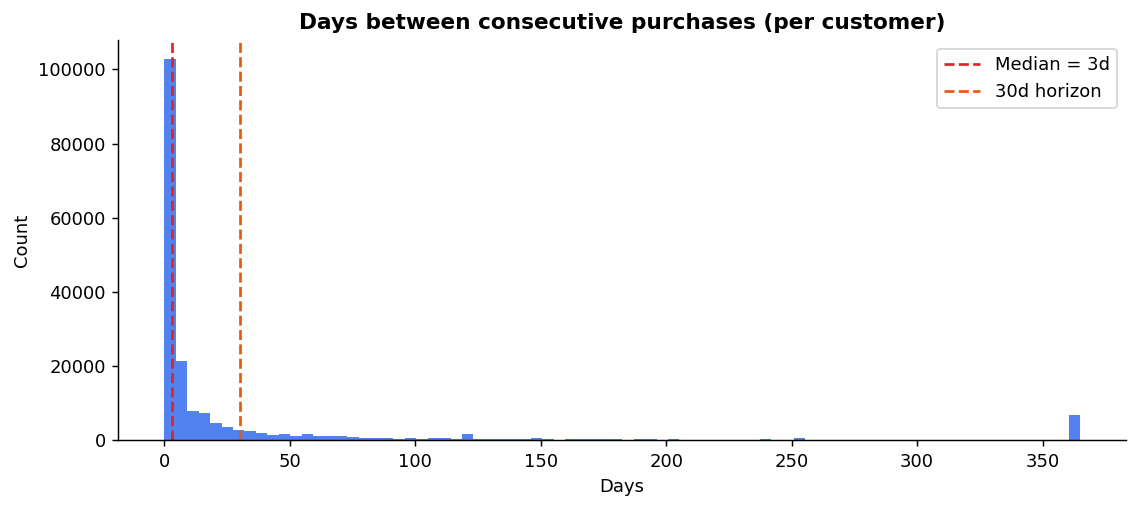

count    185492.000000
mean         49.155274
std         162.861207
min           0.000000
25%           0.000000
50%           3.000000
75%          18.000000
90%          99.000000
95%         242.000000
max        1792.000000
Name: days_between, dtype: float64

Доля покупок в течение 30 дн с прошлой: 80.6%


In [63]:
# Распределение интервала между покупками
buys = tx[tx["transactionType"] == "Buy"].sort_values(["customerID", "timestamp"])
buys["prev_buy"] = buys.groupby("customerID")["timestamp"].shift(1)
buys["days_between"] = (buys["timestamp"] - buys["prev_buy"]).dt.days
days_between = buys["days_between"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(days_between.clip(upper=365), bins=80, color=BLUE, alpha=0.8)
ax.axvline(days_between.median(), color=RED, ls="--", lw=1.5, label=f"Median = {days_between.median():.0f}d")
ax.axvline(30, color=ORANGE, ls="--", lw=1.5, label="30d horizon")
ax.set_title("Days between consecutive purchases (per customer)", fontweight="bold")
ax.set_xlabel("Days")
ax.set_ylabel("Count")
ax.legend()
plt.savefig(EDA_DIR / "days_between_purchases.png", dpi=150, bbox_inches="tight")
plt.show()

print(days_between.describe(percentiles=[.25, .5, .75, .90, .95]))
print(f"\nДоля покупок в течение 30 дн с прошлой: "
      f"{(days_between <= 30).mean():.1%}")

⚠️ На что обратить внимание
Нули (0 дней) → возможно:
несколько покупок в один день
стоит проверить агрегацию (нужно ли их схлопывать)

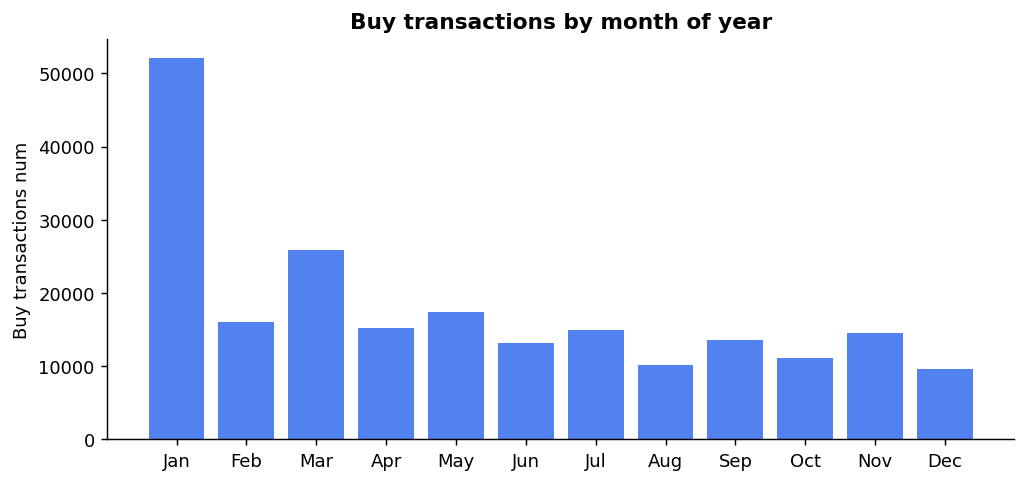

In [64]:
# Сезонность покупок по месяцам
buys["month"] = buys["timestamp"].dt.month
monthly_buys = buys.groupby("month").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_buys.index, monthly_buys.values, color=BLUE, alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Buy transactions by month of year", fontweight="bold")
ax.set_ylabel("Buy transactions num")
plt.savefig(EDA_DIR / "seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

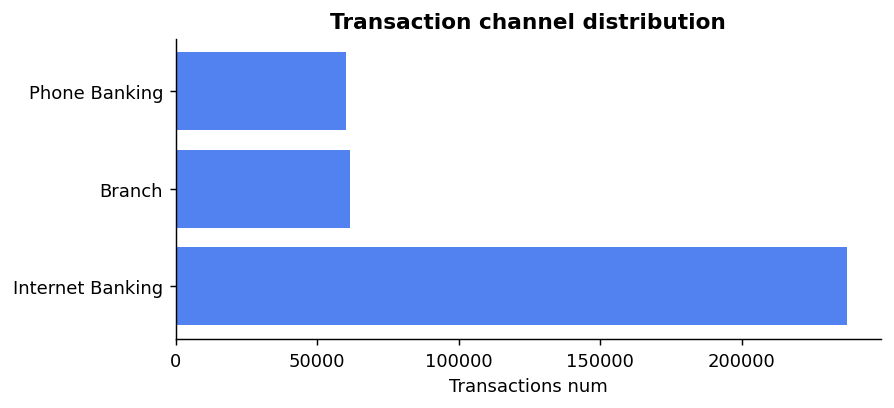

In [65]:
# Каналы покупки
channel_vc = tx["channel"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(channel_vc.index, channel_vc.values, color=BLUE, alpha=0.8)
ax.set_title("Transaction channel distribution", fontweight="bold")
ax.set_xlabel("Transactions num")
plt.savefig(EDA_DIR / "channels.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Состав портфеля

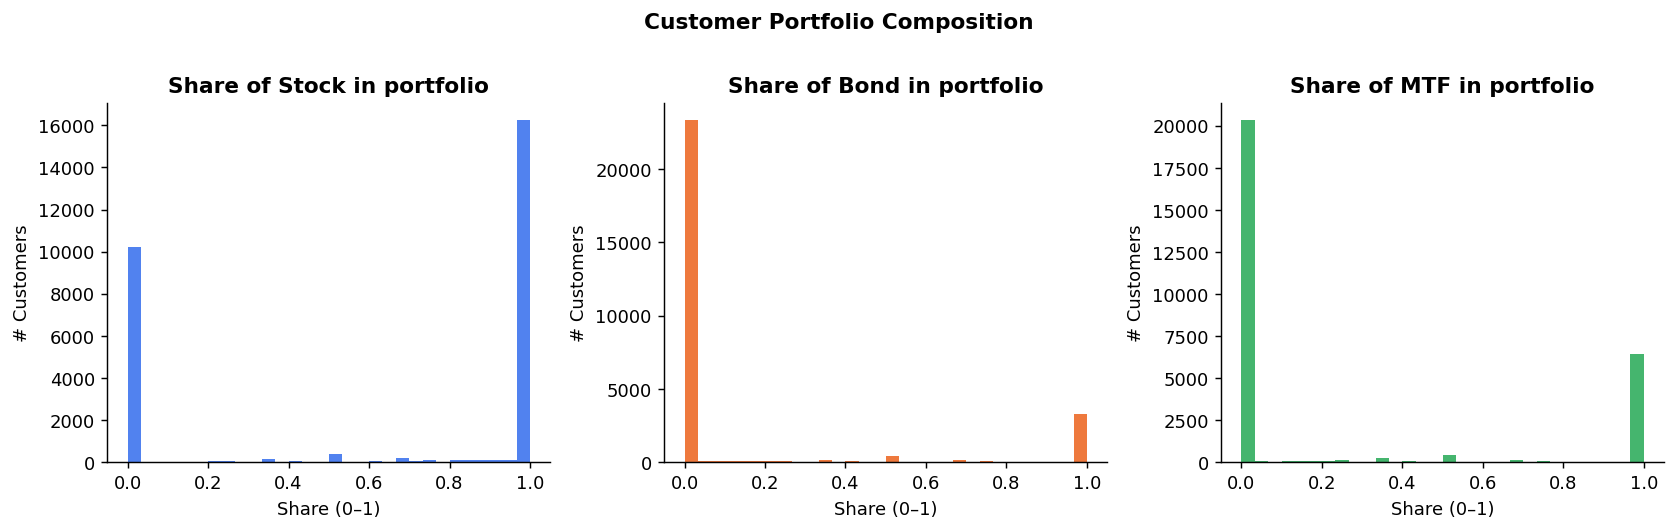

Клиенты с портфелем только из акций: 16,126
Клиенты со смешанным портфелем: 2,336


In [66]:
# Объединяем покупки с категорией актива
buys_cat = buys.merge(assets[["ISIN", "assetCategory"]], on="ISIN", how="left")

# Определяем доминирующий класс активов для каждого клиента
customer_portfolio = (buys_cat.groupby(["customerID", "assetCategory"]).size().unstack(fill_value=0))

for col in ["Stock", "Bond", "MTF"]:
    if col not in customer_portfolio.columns:
        customer_portfolio[col] = 0

total = customer_portfolio.sum(axis=1).replace(0, np.nan)
shares = customer_portfolio.div(total, axis=0).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes, ["Stock", "Bond", "MTF"], [BLUE, ORANGE, GREEN]):
    ax.hist(shares[col], bins=30, color=color, alpha=0.8)
    ax.set_title(f"Share of {col} in portfolio", fontweight="bold")
    ax.set_xlabel("Share (0–1)")
    ax.set_ylabel("# Customers")

plt.suptitle("Customer Portfolio Composition", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / "portfolio_composition.png", dpi=150, bbox_inches="tight")
plt.show()

print("Клиенты с портфелем только из акций: "
      f"{(shares['Stock'] == 1.0).sum():,}")
print("Клиенты со смешанным портфелем: "
      f"{((shares > 0).sum(axis=1) > 1).sum():,}")

## 10. Саммари

In [67]:
print("=" * 60)
print("ИТОГИ EDA")
print("=" * 60)

print()
print(f"ДИАПАЗОН ДАТ")
print(f"  Полный период: {tx['timestamp'].min().date()} → {tx['timestamp'].max().date()}")
print(f"  Определяем TRAIN_END / VALID_END в config.py, исходя из секции 7")

print()
print(f"ДИСБАЛАНС КЛАССОВ")
print(f"  Медианная доля положительного класса = {imbalance_df['pos_rate'].median():.2%}")
print(f"  - CatBoost auto_class_weights='Balanced' подходит")
print(f"  - Используем PR-AUC как основную метрику, а не ROC-AUC")

print()
print(f"КАЧЕСТВО ДАННЫХ ПРОФИЛЯ")
predicted_share = cust.sort_values("timestamp").groupby("customerID").last()["is_profile_predicted"].mean()
print(f"  {predicted_share:.1%} клиентов имеют предсказанные поля risk/capacity")
print(f"  - Признак is_profile_predicted значим, оставляем его")

print()
print(f"COLD-START КЛИЕНТЫ")
tenure = (tx.groupby("customerID")["timestamp"].max() -
          tx.groupby("customerID")["timestamp"].min()).dt.days
n_cold = (tenure < 90).sum()
print(f"  {n_cold:,} клиентов ({n_cold/len(tenure):.1%}) имеют стаж < 90 дней")
print(f"  - Флаг is_new_customer будет информативен")

print()
print(f"СЕЗОННОСТЬ")
peak_month = buys.groupby("month").size().idxmax()
print(f"  Пик покупок в месяце: {peak_month}, связан с синтетическими восстановительными транзакциями - добавлены задним числом, чтобы объяснить будущие продажи")
print(f"  Для feature engineering их нужно помечать и при необходимости исключать из расчетов определенных фичей")
print()
print("Фигуры EDA сохранены в:", EDA_DIR.resolve())

ИТОГИ EDA

ДИАПАЗОН ДАТ
  Полный период: 2018-01-02 → 2022-11-30
  Определяем TRAIN_END / VALID_END в config.py, исходя из секции 7

ДИСБАЛАНС КЛАССОВ
  Медианная доля положительного класса = 9.52%
  - CatBoost auto_class_weights='Balanced' подходит
  - Используем PR-AUC как основную метрику, а не ROC-AUC

КАЧЕСТВО ДАННЫХ ПРОФИЛЯ
  25.2% клиентов имеют предсказанные поля risk/capacity
  - Признак is_profile_predicted значим, оставляем его

COLD-START КЛИЕНТЫ
  6,165 клиентов (21.8%) имеют стаж < 90 дней
  - Флаг is_new_customer будет информативен

СЕЗОННОСТЬ
  Пик покупок в месяце: 1, связан с синтетическими восстановительными транзакциями - добавлены задним числом, чтобы объяснить будущие продажи
  Для feature engineering их нужно помечать и при необходимости исключать из расчетов определенных фичей

Фигуры EDA сохранены в: /Users/egor/Documents/Учеба файлы/ВКР/project/propensity_model/outputs/eda


# 11. ДОПОЛНИТЕЛЬНО: Cadence analysis

In [68]:
SNAPSHOT_DATE = pd.Timestamp("2021-06-01")
REACTIVATION_HORIZON = 30

print("=" * 60)
print("CADENCE ANALYSIS")
print("=" * 60)

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")
print(f"Reactivation horizon: {REACTIVATION_HORIZON} days")

CADENCE ANALYSIS
Snapshot date: 2021-06-01
Reactivation horizon: 30 days


In [69]:
# Используем только Buy-транзакции
buys = (
    tx[tx["transactionType"] == "Buy"]
    .sort_values(["customerID", "timestamp"])
    .copy()
)

# Если есть синтетические транзакции — исключаем
if "is_synthetic" in buys.columns:
    buys = buys[buys["is_synthetic"] == 0]

print(f"Buy transactions: {len(buys):,}")
print(f"Customers: {buys['customerID'].nunique():,}")

Buy transactions: 175,620
Customers: 14,019


## Расчет cadence-признаков

In [70]:
hist = buys[buys["timestamp"] <= SNAPSHOT_DATE].copy()

cadence = (
    hist.groupby("customerID")["timestamp"]
    .agg(["count", "min", "max"])
    .rename(columns={
        "count": "n_buys",
        "min": "first_buy",
        "max": "last_buy"
    })
)

cadence["current_pause_days"] = (
    SNAPSHOT_DATE - cadence["last_buy"]
).dt.days


def compute_gap_stats(grp):
    diffs = grp.sort_values().diff().dt.days.dropna()

    if len(diffs) == 0:
        return pd.Series({
            "median_interval": np.nan,
            "std_interval": np.nan,
            "max_interval": np.nan,
        })

    return pd.Series({
        "median_interval": diffs.median(),
        "std_interval": diffs.std(),
        "max_interval": diffs.max(),
    })


gap_stats = (
    hist.groupby("customerID")["timestamp"]
    .apply(compute_gap_stats)
    .unstack()
)

cadence = cadence.join(gap_stats)

cadence["cv"] = (
    cadence["std_interval"] /
    cadence["median_interval"].clip(lower=1)
)

cadence["personal_threshold_1_5"] = (
    cadence["median_interval"] * 1.5
).clip(lower=90)

cadence["personal_threshold_2_0"] = (
    cadence["median_interval"] * 2.0
).clip(lower=90)

cadence["has_cadence"] = cadence["median_interval"].notna().astype(int)

print(cadence.head())

                      n_buys  first_buy   last_buy  current_pause_days  \
customerID                                                               
00017496858921195E5A      28 2020-03-27 2021-05-26                   6   
0004718496C71D464F57       5 2020-10-23 2021-04-19                  43   
001270E70A4ECA1CD664       5 2020-03-09 2020-11-17                 196   
001387DFC77BD44899B2       4 2020-03-18 2021-03-19                  74   
00215BA74DB4920E04AF       2 2020-02-14 2020-05-19                 378   

                      median_interval  std_interval  max_interval          cv  \
customerID                                                                      
00017496858921195E5A              5.0     28.500462         111.0    5.700092   
0004718496C71D464F57             51.0     35.856194          76.0    0.703063   
001270E70A4ECA1CD664              5.5    118.525314         241.0   21.550057   
001387DFC77BD44899B2              0.0    211.310199         366.0  211.31019

## Reactivation target

In [71]:
future_buyers = buys[
    (buys["timestamp"] > SNAPSHOT_DATE) &
    (buys["timestamp"] <= SNAPSHOT_DATE + pd.Timedelta(days=REACTIVATION_HORIZON))
]["customerID"].unique()

cadence["reactivated"] = cadence.index.isin(future_buyers).astype(int)

print(f"Positive rate: {cadence['reactivated'].mean():.2%}")

Positive rate: 11.42%


## Кол-во покупок на клиента

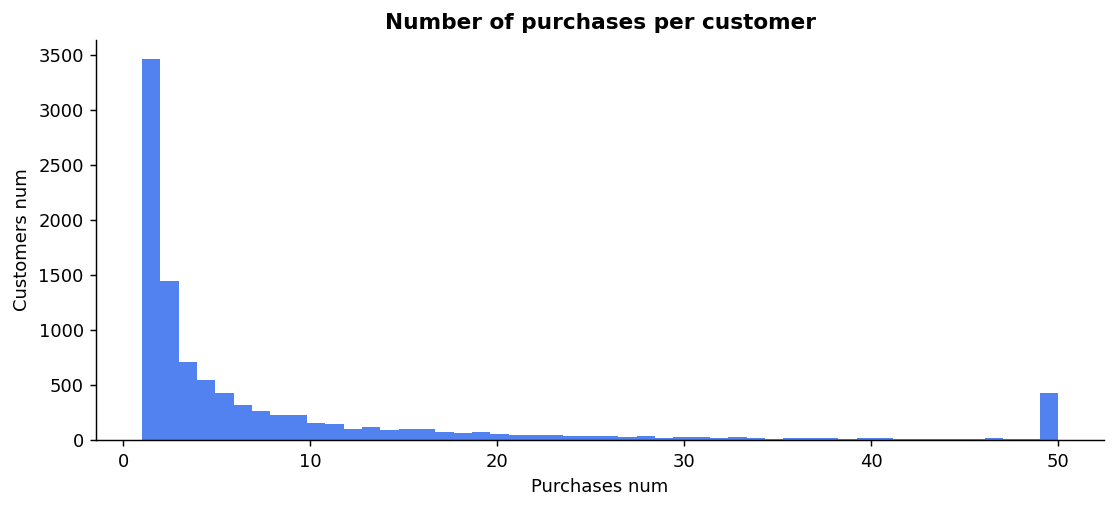

count    9826.000000
mean       11.073377
std        43.971858
min         1.000000
50%         3.000000
75%         8.000000
90%        23.000000
95%        44.000000
99%       137.250000
max      2977.000000
Name: n_buys, dtype: float64


In [72]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    cadence["n_buys"].clip(upper=50),
    bins=50,
    color=BLUE,
    alpha=0.8
)

ax.set_title(
    "Number of purchases per customer",
    fontweight="bold"
)

ax.set_xlabel("Purchases num")
ax.set_ylabel("Customers num")

plt.savefig(
    EDA_DIR / "cadence_n_buys.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(cadence["n_buys"].describe(percentiles=[.5, .75, .9, .95, .99]))

## Медианный интервал покупок

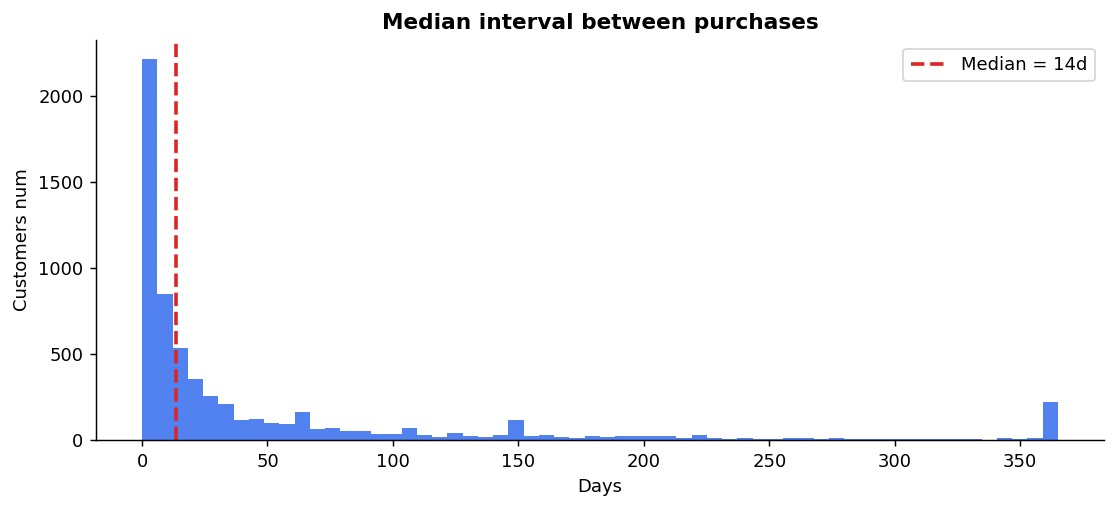

count    6358.000000
mean       57.199984
std       115.855451
min         0.000000
25%         3.000000
50%        13.500000
75%        55.000000
90%       160.150000
95%       279.150000
max      1211.000000
Name: median_interval, dtype: float64


In [73]:
has_cadence = cadence[cadence["has_cadence"] == 1].copy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    has_cadence["median_interval"].clip(upper=365),
    bins=60,
    color=BLUE,
    alpha=0.8
)

ax.axvline(
    has_cadence["median_interval"].median(),
    color=RED,
    linestyle="--",
    lw=2,
    label=f"Median = {has_cadence['median_interval'].median():.0f}d"
)

ax.set_title(
    "Median interval between purchases",
    fontweight="bold"
)

ax.set_xlabel("Days")
ax.set_ylabel("Customers num")
ax.legend()

plt.savefig(
    EDA_DIR / "cadence_median_interval.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(has_cadence["median_interval"].describe(
    percentiles=[.25, .5, .75, .9, .95]
))

## Частота покупок

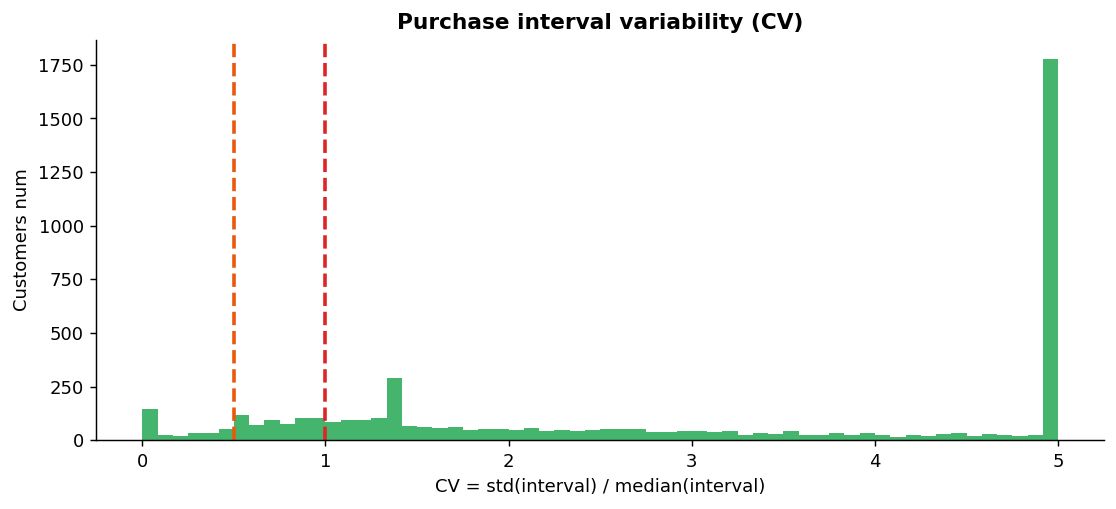

count    4914.000000
mean        2.999170
std         1.806496
min         0.000000
25%         1.315940
50%         2.924272
75%         5.000000
90%         5.000000
95%         5.000000
max         5.000000
Name: cv, dtype: float64


In [74]:
fig, ax = plt.subplots(figsize=(10, 4))

cv_values = has_cadence["cv"].dropna().clip(upper=5)

ax.hist(
    cv_values,
    bins=60,
    color=GREEN,
    alpha=0.8
)

ax.axvline(0.5, color=ORANGE, linestyle="--", lw=2)
ax.axvline(1.0, color=RED, linestyle="--", lw=2)

ax.set_title(
    "Purchase interval variability (CV)",
    fontweight="bold"
)

ax.set_xlabel("CV = std(interval) / median(interval)")
ax.set_ylabel("Customers num")

plt.savefig(
    EDA_DIR / "cadence_cv.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(cv_values.describe(percentiles=[.25, .5, .75, .9, .95]))

## Текущий период неактивности

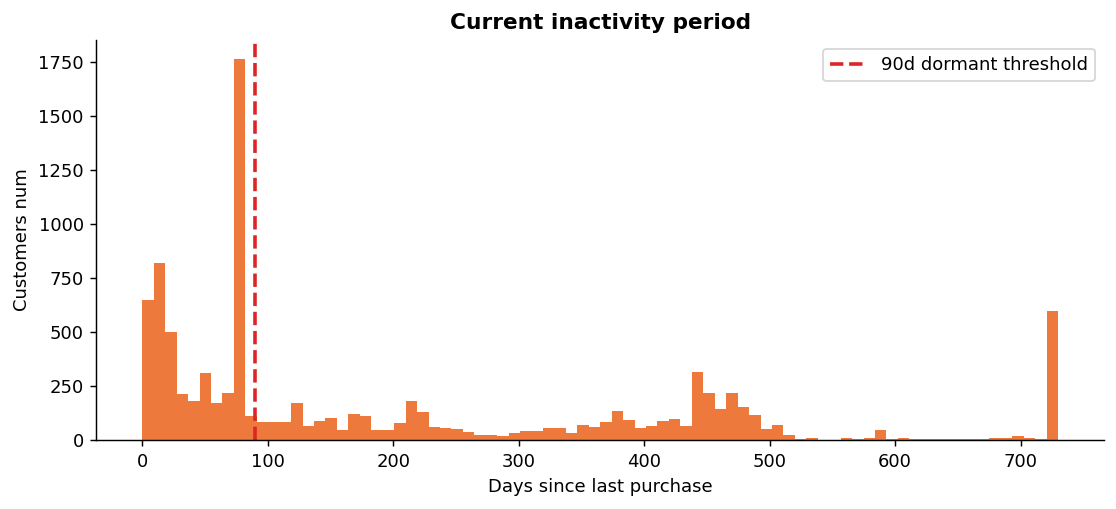

count    9826.000000
mean      231.428150
std       270.434955
min         0.000000
25%        49.000000
50%        90.000000
75%       393.000000
90%       489.000000
95%       894.750000
max      1246.000000
Name: current_pause_days, dtype: float64


In [75]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    cadence["current_pause_days"].clip(upper=730),
    bins=80,
    color=ORANGE,
    alpha=0.8
)

ax.axvline(
    90,
    color=RED,
    linestyle="--",
    lw=2,
    label="90d dormant threshold"
)

ax.set_title(
    "Current inactivity period",
    fontweight="bold"
)

ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Customers num")
ax.legend()

plt.savefig(
    EDA_DIR / "cadence_current_pause.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(cadence["current_pause_days"].describe(
    percentiles=[.25, .5, .75, .9, .95]
))

## Персональный порог покоя против фиксированного порога

In [76]:
summary = []

for threshold in [90, 180]:

    dormant = cadence[
        cadence["current_pause_days"] > threshold
    ]

    summary.append({
        "strategy": f"Fixed {threshold}d",
        "customers": len(dormant),
        "share": len(dormant) / len(cadence),
        "reactivation_rate": dormant["reactivated"].mean()
    })

# Personal threshold
eligible = has_cadence.copy()

eligible["is_dormant_personal"] = (
    eligible["current_pause_days"] >
    eligible["personal_threshold_1_5"]
)

dormant_personal = eligible[
    eligible["is_dormant_personal"]
]

summary.append({
    "strategy": "Personal 1.5×median",
    "customers": len(dormant_personal),
    "share": len(dormant_personal) / len(cadence),
    "reactivation_rate": dormant_personal["reactivated"].mean()
})

summary_df = pd.DataFrame(summary)

summary_df

,strategy,customers,share,reactivation_rate
0,Fixed 90d,4902,0.498881,0.028356
1,Fixed 180d,3952,0.402198,0.020243
2,Personal 1.5×median,2677,0.272440,0.038102


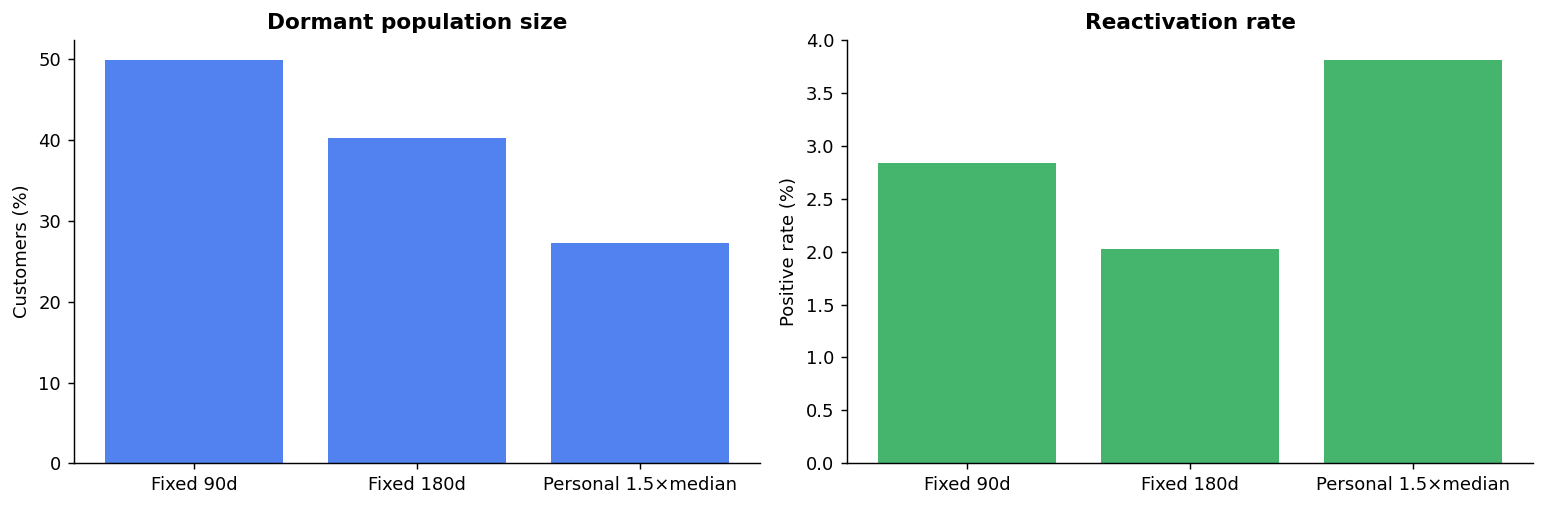

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Доля dormant
axes[0].bar(
    summary_df["strategy"],
    summary_df["share"] * 100,
    color=BLUE,
    alpha=0.8
)

axes[0].set_title(
    "Dormant population size",
    fontweight="bold"
)

axes[0].set_ylabel("Customers (%)")

# Reactivation rate
axes[1].bar(
    summary_df["strategy"],
    summary_df["reactivation_rate"] * 100,
    color=GREEN,
    alpha=0.8
)

axes[1].set_title(
    "Reactivation rate",
    fontweight="bold"
)

axes[1].set_ylabel("Positive rate (%)")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "cadence_threshold_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Pause z-score vs reactivation

In [78]:
has_cadence["pause_zscore"] = (
    (
        has_cadence["current_pause_days"] -
        has_cadence["median_interval"]
    ) /
    (has_cadence["std_interval"].fillna(1) + 1e-6)
).clip(-3, 3)

has_cadence["zscore_bucket"] = pd.qcut(
    has_cadence["pause_zscore"],
    q=4,
    duplicates="drop"
)

zscore_stats = (
    has_cadence
    .groupby("zscore_bucket", observed=True)
    .agg(
        customers=("reactivated", "size"),
        reactivation_rate=("reactivated", "mean")
    )
    .reset_index()
)

zscore_stats

,zscore_bucket,customers,reactivation_rate
0,"(-3.001, -0.0486]",1590,0.200629
1,"(-0.0486, 0.891]",1589,0.303335
2,"(0.891, 3.0]",3179,0.079585


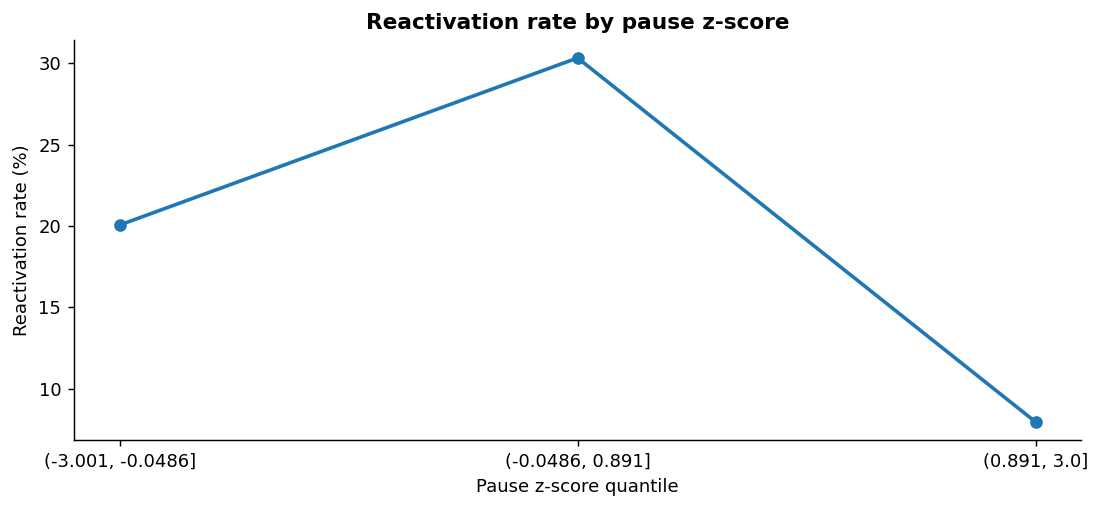

In [79]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    zscore_stats["zscore_bucket"].astype(str),
    zscore_stats["reactivation_rate"] * 100,
    marker="o",
    lw=2
)

ax.set_title(
    "Reactivation rate by pause z-score",
    fontweight="bold"
)

ax.set_xlabel("Pause z-score quantile")
ax.set_ylabel("Reactivation rate (%)")


plt.savefig(
    EDA_DIR / "cadence_zscore_reactivation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Минимальное кол-во транзакций

In [80]:
buy_counts = (
    buys.groupby("customerID")
    .size()
)

records = []

for min_tx in [5, 8, 10, 15, 20]:

    eligible = buy_counts[buy_counts >= min_tx]

    records.append({
        "MIN_TX_REACT": min_tx,
        "eligible_customers": len(eligible),
        "share_of_customers": len(eligible) / len(buy_counts),
        "median_buys": eligible.median(),
        "mean_buys": eligible.mean(),
    })

min_tx_df = pd.DataFrame(records)

min_tx_df

,MIN_TX_REACT,eligible_customers,share_of_customers,median_buys,mean_buys
0,5,4787,0.341465,13.0,33.191978
1,8,3490,0.248948,19.0,43.375358
2,10,2946,0.210143,23.0,49.819077
3,15,2187,0.156003,31.0,63.038409
4,20,1711,0.122049,41.0,75.876096


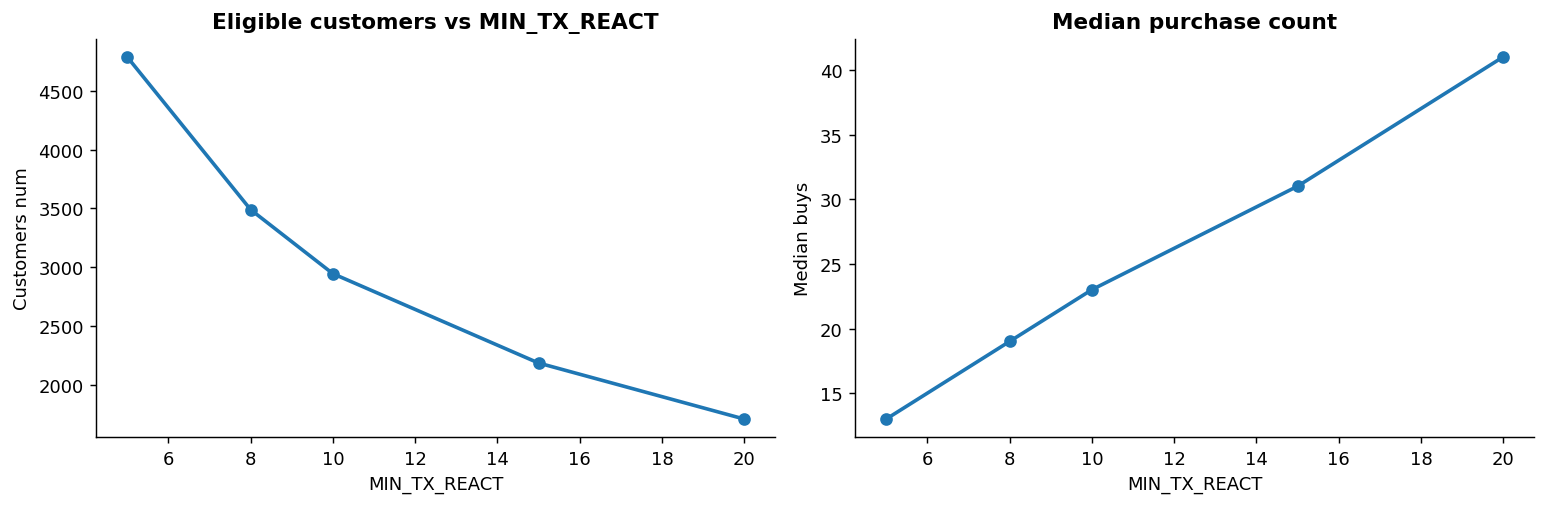

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Размер выборки
axes[0].plot(
    min_tx_df["MIN_TX_REACT"],
    min_tx_df["eligible_customers"],
    marker="o",
    lw=2
)

axes[0].set_title(
    "Eligible customers vs MIN_TX_REACT",
    fontweight="bold"
)

axes[0].set_xlabel("MIN_TX_REACT")
axes[0].set_ylabel("Customers num")

# Median buys
axes[1].plot(
    min_tx_df["MIN_TX_REACT"],
    min_tx_df["median_buys"],
    marker="o",
    lw=2
)

axes[1].set_title(
    "Median purchase count",
    fontweight="bold"
)

axes[1].set_xlabel("MIN_TX_REACT")
axes[1].set_ylabel("Median buys")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "min_tx_react_sensitivity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Выводы

In [82]:
print("=" * 60)
print("CADENCE INSIGHTS")
print("=" * 60)

median_interval = has_cadence["median_interval"].median()

pct_short = (
    has_cadence["median_interval"] <= 30
).mean()

pct_long = (
    has_cadence["median_interval"] >= 90
).mean()

pct_regular = (
    has_cadence["cv"] < 0.5
).mean()

print()
print(f"Median customer purchase interval: {median_interval:.0f} days")
print(f"Customers with interval <=30d: {pct_short:.1%}")
print(f"Customers with interval >=90d: {pct_long:.1%}")
print(f"Regular customers (CV < 0.5): {pct_regular:.1%}")

print()
print("Conclusions:")

if median_interval <= 30:
    print("- Most customers purchase frequently")
    print("- Fixed 90d dormant threshold is conservative enough")
else:
    print("- Customer cadence differs significantly")
    print("- Personal thresholds should improve dormant detection")

if pct_regular < 0.3:
    print("- Most customers are behaviorally irregular")
    print("- Cadence-only features may be weak predictors")

print()
print("Cadence figures saved to:", EDA_DIR.resolve())

CADENCE INSIGHTS

Median customer purchase interval: 14 days
Customers with interval <=30d: 66.4%
Customers with interval >=90d: 17.5%
Regular customers (CV < 0.5): 5.0%

Conclusions:
- Most customers purchase frequently
- Fixed 90d dormant threshold is conservative enough
- Most customers are behaviorally irregular
- Cadence-only features may be weak predictors

Cadence figures saved to: /Users/egor/Documents/Учеба файлы/ВКР/project/propensity_model/outputs/eda
